# Instruction (Read this)
- Use this template to develop your project. Do not change the steps. 
- For each step, you may add additional cells if needed.
- But remove <b>unnecessary</b> cells to ensure the notebook is readable.
- Marks will be <b>deducted</b> if the notebook is cluttered or difficult to follow due to excess or irrelevant content.
- <b>Briefly</b> describe the steps in the "Description:" field.
- <b>Do not</b> submit the dataset. 
- The submitted jupyter notebook will be executed using the uploaded dataset in eLearn.

# Group Information

Group No:

- Member 1: CH'NG BAO SHENG (23302782)
- Member 2: LIM YONG ZHOU (23302902)
- Member 3: JEFFRY SOO YU ZHEN (23304759)

# Import Necessary Libraries

## Core Data Handling

In [1]:
import pandas as pd # for data manipulation
import warnings # for warning control
warnings.filterwarnings('ignore') # ignore warning messages


## Numerics and Array Operations

In [2]:
import numpy as np # for numerical operations

## Machine Learning Algorithms and Utilities

In [3]:
from sklearn.ensemble import RandomForestClassifier # for Random Forest classifier
from sklearn.neural_network import MLPClassifier # for MLP Neural Network classifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV # for data splits, CV, and tuning
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.feature_selection import mutual_info_classif # for Mutual Information feature selection
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
) # for model evaluation metrics


## Visualization

In [4]:
import matplotlib.pyplot as plt # for plotting graphs
import seaborn as sns # for enhanced data visualization

# Load the Dataset

In [5]:
# Define column names based on the Dermatology dataset README
columns = [
    'erythema',
    'scaling',
    'definite_borders',
    'itching',
    'koebner_phenomenon',
    'polygonal_papules',
    'follicular_papules',
    'oral_mucosal_involvement',
    'knee_and_elbow_involvement',
    'scalp_involvement',
    'family_history',
    'melanin_incontinence',
    'eosinophils_in_the_infiltrate',
    'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis',
    'exocytosis',
    'acanthosis',
    'hyperkeratosis',
    'parakeratosis',
    'clubbing_of_the_rete_ridges',
    'elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule',
    'munro_microabcess',
    'focal_hypergranulosis',
    'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer',
    'spongiosis',
    'saw_tooth_appearance_of_retes',
    'follicular_horn_plug',
    'perifollicular_parakeratosis',
    'inflammatory_mononuclear_infiltrate',
    'band_like_infiltrate',
    'age',
    'class'
]

# Load the dataset without headers and convert '?' missing values to NaN
df = pd.read_csv(
    'Project Datasets/Dermatology/dermatology.csv',
    header=None,
    names=columns,
    na_values='?'
)

# Display the first five rows of the dataset
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


# Exploratory Data Analysis (EDA)

## Initial Analysis of Dataset

In [6]:
print('Dataset dimension:', df.shape) # Display the number of rows and columns
print('Number of features:', df.drop(columns=['class']).shape[1]) # Display the number of input features
print('Columns of features:', df.drop(columns=['class']).columns) # Display all feature column names
print('Target column: class') # Display the target column name

Dataset dimension: (366, 35)
Number of features: 34
Columns of features: Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw_tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate', 'age'],


## Data Types of Dataset

In [7]:
df.info() # Display column names, data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                            366 non

## Descriptive Statistics for Numeric Columns

In [8]:
df.describe() # Display descriptive statistics for numeric columns

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,358.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,36.296089,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,15.324557,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,25.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,35.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,49.750000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,75.000000,6.000000


# Data Preparation
______________________________________________________________________________________
Description: Missing values, duplicate rows, and outlier considerations are handled before checking the final class distribution and splitting the dataset.

## Data Cleaning

### Handling Missing Values

In [9]:
missing_counts = df.isnull().sum() # Count missing values for each column
missing_counts[missing_counts > 0] # Display only columns with missing values

age    8
dtype: int64

In [10]:
age_median = df['age'].median() # Calculate the median age for imputation
df['age'] = df['age'].fillna(age_median) # Replace missing age values with the median age

print('Median age used for imputation:', age_median) # Display the median value used
print('Total missing values after imputation:', df.isnull().sum().sum()) # Check remaining missing values

Median age used for imputation: 35.0
Total missing values after imputation: 0


### Handling Duplicate Rows

In [11]:
duplicate_count = df.duplicated().sum() # Count duplicate rows in the dataset
print('Number of duplicate rows:', duplicate_count) # Display the number of duplicated rows

# Remove duplicate rows if any are found
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True) # Drop duplicates and reset the index
    print('Duplicates removed. New dataset dimension:', df.shape) # Display new dataset dimension
else:
    print('No duplicate rows were found.') # Inform that no duplicates were found

Number of duplicate rows: 0
No duplicate rows were found.


## Outlier Checking
Most dermatology features are ordinal clinical or histopathological scores from 0 to 3. Therefore, values in this range are valid medical severity levels rather than statistical outliers. Only `age` is inspected separately, and rows are not removed using IQR to avoid deleting valid medical cases from a small dataset.

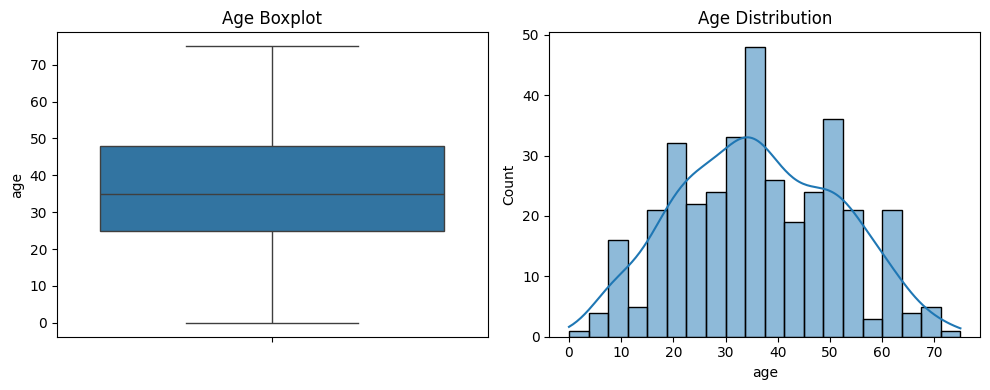

In [12]:
plt.figure(figsize=(10, 4)) # Set the figure size for side-by-side plots

plt.subplot(1, 2, 1) # Create the first subplot for boxplot
sns.boxplot(y=df['age']) # Plot age values to inspect possible outliers
plt.title('Age Boxplot') # Set title for the boxplot

plt.subplot(1, 2, 2) # Create the second subplot for histogram
sns.histplot(df['age'], bins=20, kde=True) # Plot the distribution of age
plt.title('Age Distribution') # Set title for the histogram

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show() # Display the plots

## Class Distribution After Cleaning

In [13]:
# Define class labels based on the Dermatology dataset README
class_names = {
    1: 'psoriasis',
    2: 'seboreic dermatitis',
    3: 'lichen planus',
    4: 'pityriasis rosea',
    5: 'cronic dermatitis',
    6: 'pityriasis rubra pilaris'
}

# Count the number of instances for each disease class after cleaning
class_distribution = df['class'].value_counts().sort_index()

# Convert the class distribution into a DataFrame for clearer display
class_distribution_df = class_distribution.rename_axis('class').reset_index(name='count')

# Map each class number to its disease name
class_distribution_df['disease'] = class_distribution_df['class'].map(class_names)

# Display the final class distribution table before splitting
class_distribution_df

,class,count,disease
0,1,112,psoriasis
1,2,61,seboreic dermatitis
2,3,72,lichen planus
3,4,49,pityriasis rosea
4,5,52,cronic dermatitis
5,6,20,pityriasis rubra pilaris


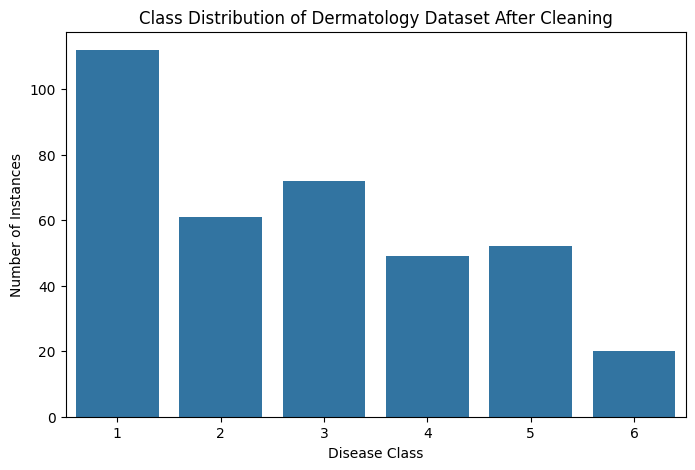

In [14]:
plt.figure(figsize=(8, 5)) # Set the figure size
sns.countplot(data=df, x='class', order=sorted(df['class'].unique())) # Plot the number of records for each class
plt.title('Class Distribution of Dermatology Dataset After Cleaning') # Set the chart title
plt.xlabel('Disease Class') # Set x-axis label
plt.ylabel('Number of Instances') # Set y-axis label
plt.show() # Display the plot

# Split the Dataset
Split the dataset into training, validation, and test sets. Three stratified split ratios are prepared: 80/10/10, 70/15/15, and 60/20/20.

In [15]:
X = df.drop(columns=['class']) # Select all input features
y = df['class'] # Select the multi-class target variable

print('All feature data types:') # Display the data types of all input features
print(X.dtypes.value_counts()) # Count the number of columns for each data type
print('\nTarget classes:', sorted(y.unique())) # Display unique target classes

All feature data types:
int64      33
float64     1
Name: count, dtype: int64

Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [16]:
# Split the dataset into 80% training data and 20% temporary data for the 80/10/10 split
x_train_80, x_temp_20_for_80, y_train_80, y_temp_20_for_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split the temporary 20% data equally into 10% validation data and 10% test data
x_val_10, x_test_10, y_val_10, y_test_10 = train_test_split(
    x_temp_20_for_80,
    y_temp_20_for_80,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_20_for_80
)

# Split the dataset into 70% training data and 30% temporary data for the 70/15/15 split
x_train_70, x_temp_30_for_70, y_train_70, y_temp_30_for_70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the temporary 30% data equally into 15% validation data and 15% test data
x_val_15, x_test_15, y_val_15, y_test_15 = train_test_split(
    x_temp_30_for_70,
    y_temp_30_for_70,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_30_for_70
)

# Split the dataset into 60% training data and 40% temporary data for the 60/20/20 split
x_train_60, x_temp_40_for_60, y_train_60, y_temp_40_for_60 = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Split the temporary 40% data equally into 20% validation data and 20% test data
x_val_20, x_test_20, y_val_20, y_test_20 = train_test_split(
    x_temp_40_for_60,
    y_temp_40_for_60,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_40_for_60
)

# Store all explicit split variables in a dictionary for easier looping in later preprocessing steps
split_datasets = {
    '80_10_10': {
        'X_train': x_train_80,
        'X_val': x_val_10,
        'X_test': x_test_10,
        'y_train': y_train_80,
        'y_val': y_val_10,
        'y_test': y_test_10
    },
    '70_15_15': {
        'X_train': x_train_70,
        'X_val': x_val_15,
        'X_test': x_test_15,
        'y_train': y_train_70,
        'y_val': y_val_15,
        'y_test': y_test_15
    },
    '60_20_20': {
        'X_train': x_train_60,
        'X_val': x_val_20,
        'X_test': x_test_20,
        'y_train': y_train_60,
        'y_val': y_val_20,
        'y_test': y_test_20
    }
}

# Display the dimensions of each explicit split dataset
print('80/10/10 split')
print('x_train_80:', x_train_80.shape, 'y_train_80:', y_train_80.shape)
print('x_val_10:', x_val_10.shape, 'y_val_10:', y_val_10.shape)
print('x_test_10:', x_test_10.shape, 'y_test_10:', y_test_10.shape)
print('-' * 50)

print('70/15/15 split')
print('x_train_70:', x_train_70.shape, 'y_train_70:', y_train_70.shape)
print('x_val_15:', x_val_15.shape, 'y_val_15:', y_val_15.shape)
print('x_test_15:', x_test_15.shape, 'y_test_15:', y_test_15.shape)
print('-' * 50)

print('60/20/20 split')
print('x_train_60:', x_train_60.shape, 'y_train_60:', y_train_60.shape)
print('x_val_20:', x_val_20.shape, 'y_val_20:', y_val_20.shape)
print('x_test_20:', x_test_20.shape, 'y_test_20:', y_test_20.shape)

80/10/10 split
x_train_80: (292, 34) y_train_80: (292,)
x_val_10: (37, 34) y_val_10: (37,)
x_test_10: (37, 34) y_test_10: (37,)
--------------------------------------------------
70/15/15 split
x_train_70: (256, 34) y_train_70: (256,)
x_val_15: (55, 34) y_val_15: (55,)
x_test_15: (55, 34) y_test_15: (55,)
--------------------------------------------------
60/20/20 split
x_train_60: (219, 34) y_train_60: (219,)
x_val_20: (73, 34) y_val_20: (73,)
x_test_20: (74, 34) y_test_20: (74,)


In [17]:
# Display the class distribution for each train, validation and test split
for split_name, data in split_datasets.items():
    split_distribution = pd.DataFrame({
        'train': data['y_train'].value_counts().sort_index(),
        'validation': data['y_val'].value_counts().sort_index(),
        'test': data['y_test'].value_counts().sort_index()
    })

    print(f'Class distribution for {split_name} split') # Display split name
    display(split_distribution) # Display the class distribution table for the split

Class distribution for 80_10_10 split


,train,validation,test
class,,,
1,89,11,12
2,49,6,6
3,57,8,7
4,39,5,5
5,42,5,5
6,16,2,2


Class distribution for 70_15_15 split


,train,validation,test
class,,,
1,78,17,17
2,43,9,9
3,50,11,11
4,34,7,8
5,37,8,7
6,14,3,3


Class distribution for 60_20_20 split


,train,validation,test
class,,,
1,67,22,23
2,37,12,12
3,43,14,15
4,29,10,10
5,31,11,10
6,12,4,4


In [18]:
# Use the 70/15/15 split as the default split for the remaining preprocessing examples
X_train = x_train_70 # Default training features
X_val = x_val_15 # Default validation features
X_test = x_test_15 # Default test features
y_train = y_train_70 # Default training target
y_val = y_val_15 # Default validation target
y_test = y_test_15 # Default test target

# Data Preprocessing
Perform data preprocessing such as normalization, standardization, label encoding etc.
______________________________________________________________________________________
Description: Label encoding is not required because all attributes and class labels are already numeric. Standardization is applied after splitting. Each scaler is fitted only on its training set, then applied to the matching validation and test sets to avoid data leakage.

In [19]:
# Create separate StandardScaler objects for each split ratio
scaler_80_10_10 = StandardScaler() # Scaler for 80/10/10 split
scaler_70_15_15 = StandardScaler() # Scaler for 70/15/15 split
scaler_60_20_20 = StandardScaler() # Scaler for 60/20/20 split

# Fit the scaler on 80% training data and transform the matching validation and test data
x_train_80_scaled = scaler_80_10_10.fit_transform(x_train_80) # Fit and transform 80% training features
x_val_10_scaled = scaler_80_10_10.transform(x_val_10) # Transform 10% validation features
x_test_10_scaled = scaler_80_10_10.transform(x_test_10) # Transform 10% test features

# Convert the 80/10/10 scaled arrays back into DataFrames
x_train_80_scaled_df = pd.DataFrame(x_train_80_scaled, columns=X.columns, index=x_train_80.index)
x_val_10_scaled_df = pd.DataFrame(x_val_10_scaled, columns=X.columns, index=x_val_10.index)
x_test_10_scaled_df = pd.DataFrame(x_test_10_scaled, columns=X.columns, index=x_test_10.index)

# Fit the scaler on 70% training data and transform the matching validation and test data
x_train_70_scaled = scaler_70_15_15.fit_transform(x_train_70) # Fit and transform 70% training features
x_val_15_scaled = scaler_70_15_15.transform(x_val_15) # Transform 15% validation features
x_test_15_scaled = scaler_70_15_15.transform(x_test_15) # Transform 15% test features

# Convert the 70/15/15 scaled arrays back into DataFrames
x_train_70_scaled_df = pd.DataFrame(x_train_70_scaled, columns=X.columns, index=x_train_70.index)
x_val_15_scaled_df = pd.DataFrame(x_val_15_scaled, columns=X.columns, index=x_val_15.index)
x_test_15_scaled_df = pd.DataFrame(x_test_15_scaled, columns=X.columns, index=x_test_15.index)

# Fit the scaler on 60% training data and transform the matching validation and test data
x_train_60_scaled = scaler_60_20_20.fit_transform(x_train_60) # Fit and transform 60% training features
x_val_20_scaled = scaler_60_20_20.transform(x_val_20) # Transform 20% validation features
x_test_20_scaled = scaler_60_20_20.transform(x_test_20) # Transform 20% test features

# Convert the 60/20/20 scaled arrays back into DataFrames
x_train_60_scaled_df = pd.DataFrame(x_train_60_scaled, columns=X.columns, index=x_train_60.index)
x_val_20_scaled_df = pd.DataFrame(x_val_20_scaled, columns=X.columns, index=x_val_20.index)
x_test_20_scaled_df = pd.DataFrame(x_test_20_scaled, columns=X.columns, index=x_test_20.index)

# Store all explicit scaled variables in a dictionary for easier looping in later model training
scaled_datasets = {
    '80_10_10': {
        'X_train_scaled': x_train_80_scaled_df,
        'X_val_scaled': x_val_10_scaled_df,
        'X_test_scaled': x_test_10_scaled_df,
        'y_train': y_train_80,
        'y_val': y_val_10,
        'y_test': y_test_10,
        'scaler': scaler_80_10_10
    },
    '70_15_15': {
        'X_train_scaled': x_train_70_scaled_df,
        'X_val_scaled': x_val_15_scaled_df,
        'X_test_scaled': x_test_15_scaled_df,
        'y_train': y_train_70,
        'y_val': y_val_15,
        'y_test': y_test_15,
        'scaler': scaler_70_15_15
    },
    '60_20_20': {
        'X_train_scaled': x_train_60_scaled_df,
        'X_val_scaled': x_val_20_scaled_df,
        'X_test_scaled': x_test_20_scaled_df,
        'y_train': y_train_60,
        'y_val': y_val_20,
        'y_test': y_test_20,
        'scaler': scaler_60_20_20
    }
}

# Display the first five rows of the scaled training features for the default 70/15/15 split
x_train_70_scaled_df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age
273,-0.072286,0.268991,1.576253,-0.343212,-0.678289,-0.462741,-0.299271,-0.448523,2.461330,1.769005,...,-0.474377,1.751751,-0.482668,-0.888264,-0.470526,-0.23858,-0.233493,1.545793,-0.503066,1.348490
317,-0.072286,0.268991,0.485656,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,1.430069,1.769005,...,-0.474377,1.751751,-0.482668,-0.888264,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,0.696036
46,-0.072286,-1.136351,-0.604940,1.449894,2.704347,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,-0.524636,-0.482668,-0.003456,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,0.630791
270,-0.072286,0.268991,-0.604940,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,0.613558,-0.482668,1.766158,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,1.674717
256,-0.072286,-1.136351,-0.604940,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,0.613558,-0.482668,0.881351,-0.470526,-0.23858,-0.233493,-1.183331,-0.503066,-0.086909


In [20]:
# Store default scaled datasets for easier use in the next preprocessing steps
X_train_scaled_df = x_train_70_scaled_df # Default scaled training features
X_val_scaled_df = x_val_15_scaled_df # Default scaled validation features
X_test_scaled_df = x_test_15_scaled_df # Default scaled test features

## Prepare Datasets for Random Forest and MLP Neural Network
MLP Neural Networks are sensitive to feature scale, so the scaled datasets are used for MLP. Random Forest is not sensitive to feature scale, but for consistency and to use the same feature selection pipeline, the scaled datasets are prepared for both algorithms. The same train, validation and test splits are reused to ensure a fair comparison.

In [21]:
# Prepare explicit scaled datasets for Random Forest using 80/10/10 split
rf_x_train_80 = x_train_80_scaled_df # Random Forest training features for 80/10/10 split
rf_x_val_10 = x_val_10_scaled_df # Random Forest validation features for 80/10/10 split
rf_x_test_10 = x_test_10_scaled_df # Random Forest test features for 80/10/10 split
rf_y_train_80 = y_train_80 # Random Forest training target for 80/10/10 split
rf_y_val_10 = y_val_10 # Random Forest validation target for 80/10/10 split
rf_y_test_10 = y_test_10 # Random Forest test target for 80/10/10 split

# Prepare explicit scaled datasets for Random Forest using 70/15/15 split
rf_x_train_70 = x_train_70_scaled_df # Random Forest training features for 70/15/15 split
rf_x_val_15 = x_val_15_scaled_df # Random Forest validation features for 70/15/15 split
rf_x_test_15 = x_test_15_scaled_df # Random Forest test features for 70/15/15 split
rf_y_train_70 = y_train_70 # Random Forest training target for 70/15/15 split
rf_y_val_15 = y_val_15 # Random Forest validation target for 70/15/15 split
rf_y_test_15 = y_test_15 # Random Forest test target for 70/15/15 split

# Prepare explicit scaled datasets for Random Forest using 60/20/20 split
rf_x_train_60 = x_train_60_scaled_df # Random Forest training features for 60/20/20 split
rf_x_val_20 = x_val_20_scaled_df # Random Forest validation features for 60/20/20 split
rf_x_test_20 = x_test_20_scaled_df # Random Forest test features for 60/20/20 split
rf_y_train_60 = y_train_60 # Random Forest training target for 60/20/20 split
rf_y_val_20 = y_val_20 # Random Forest validation target for 60/20/20 split
rf_y_test_20 = y_test_20 # Random Forest test target for 60/20/20 split

# Prepare explicit scaled datasets for MLP Neural Network using 80/10/10 split
mlp_x_train_80 = x_train_80_scaled_df # MLP training features for 80/10/10 split
mlp_x_val_10 = x_val_10_scaled_df # MLP validation features for 80/10/10 split
mlp_x_test_10 = x_test_10_scaled_df # MLP test features for 80/10/10 split
mlp_y_train_80 = y_train_80 # MLP training target for 80/10/10 split
mlp_y_val_10 = y_val_10 # MLP validation target for 80/10/10 split
mlp_y_test_10 = y_test_10 # MLP test target for 80/10/10 split

# Prepare explicit scaled datasets for MLP Neural Network using 70/15/15 split
mlp_x_train_70 = x_train_70_scaled_df # MLP training features for 70/15/15 split
mlp_x_val_15 = x_val_15_scaled_df # MLP validation features for 70/15/15 split
mlp_x_test_15 = x_test_15_scaled_df # MLP test features for 70/15/15 split
mlp_y_train_70 = y_train_70 # MLP training target for 70/15/15 split
mlp_y_val_15 = y_val_15 # MLP validation target for 70/15/15 split
mlp_y_test_15 = y_test_15 # MLP test target for 70/15/15 split

# Prepare explicit scaled datasets for MLP Neural Network using 60/20/20 split
mlp_x_train_60 = x_train_60_scaled_df # MLP training features for 60/20/20 split
mlp_x_val_20 = x_val_20_scaled_df # MLP validation features for 60/20/20 split
mlp_x_test_20 = x_test_20_scaled_df # MLP test features for 60/20/20 split
mlp_y_train_60 = y_train_60 # MLP training target for 60/20/20 split
mlp_y_val_20 = y_val_20 # MLP validation target for 60/20/20 split
mlp_y_test_20 = y_test_20 # MLP test target for 60/20/20 split

print('Random Forest and MLP datasets prepared for all three split ratios.')


Random Forest and MLP datasets prepared for all three split ratios.


In [22]:
# Initialize model objects for later model training
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42) # Create Random Forest model
mlp_model = MLPClassifier(max_iter=1000, random_state=42) # Create MLP Neural Network model

print(random_forest_model) # Display Random Forest model configuration
print(mlp_model) # Display MLP model configuration


RandomForestClassifier(random_state=42)
MLPClassifier(max_iter=1000, random_state=42)


# Feature Selection
Perform feature selection to select the relevant features.
______________________________________________________________________________________
Description: Mutual Information (MI) is used as the feature selection method for both Random Forest and MLP Neural Network. MI measures the non-linear dependency between each feature and the target variable. It is model-agnostic, making it suitable as a unified feature selection approach. For each split ratio, MI scores are computed on the training set, and candidate feature counts (top 5, 10, 15, 20, 25, 30, and all 34 features) are evaluated using 5-fold Stratified Cross-Validation to identify the optimal feature subset for each model.

In [23]:
# Create a stratified 5-fold cross-validation object to preserve class proportions in each fold
mi_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define candidate feature counts to evaluate
candidate_feature_counts = [5, 10, 15, 20, 25, 30, X_train_scaled_df.shape[1]]

# Remove duplicate candidate values and keep only valid feature counts
feature_counts = sorted(set(k for k in candidate_feature_counts if 1 <= k <= X_train_scaled_df.shape[1]))

# Define the two models used for cross-validation evaluation during feature selection
mi_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
}

# Store all scaled training datasets for all three split ratios
mi_input_data = {
    '80_10_10': {
        'Random Forest': {'X_train': rf_x_train_80, 'y_train': rf_y_train_80},
        'MLP': {'X_train': mlp_x_train_80, 'y_train': mlp_y_train_80}
    },
    '70_15_15': {
        'Random Forest': {'X_train': rf_x_train_70, 'y_train': rf_y_train_70},
        'MLP': {'X_train': mlp_x_train_70, 'y_train': mlp_y_train_70}
    },
    '60_20_20': {
        'Random Forest': {'X_train': rf_x_train_60, 'y_train': rf_y_train_60},
        'MLP': {'X_train': mlp_x_train_60, 'y_train': mlp_y_train_60}
    }
}

# Create empty containers to store detailed MI results and summary rows
mi_results = {}
mi_summary_rows = []

# Loop through each split ratio so feature selection can be compared across training sizes
for split_name, split_data in mi_input_data.items():
    mi_results[split_name] = {}

    # Compute Mutual Information scores once per split using the Random Forest training data
    # (Both models share the same scaled training features, so MI scores are identical)
    X_mi = split_data['Random Forest']['X_train']
    y_mi = split_data['Random Forest']['y_train']
    mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

    # Rank features by MI score in descending order
    mi_ranking = np.argsort(mi_scores)[::-1]

    # Print the MI scores for each feature in ranked order
    print(f'\n--- MI Feature Ranking for {split_name} split ---')
    for rank, idx in enumerate(mi_ranking):
        print(f'  Rank {rank+1}: {X_mi.columns[idx]} (MI = {mi_scores[idx]:.4f})')

    # Loop through each model so Random Forest and MLP are evaluated separately
    for model_name, model in mi_models.items():
        X_eval = split_data[model_name]['X_train'] # Select the scaled training features
        y_eval = split_data[model_name]['y_train'] # Select the training target values
        model_results = [] # Store all candidate-k results for the current split and model

        # Test each candidate number of selected features
        for k in feature_counts:
            # Select the top-k features based on MI ranking
            selected_indices = mi_ranking[:k]
            selected_features = X_eval.columns[selected_indices].tolist()
            selected_X = X_eval.iloc[:, selected_indices]

            # Evaluate the selected feature subset using 5-fold cross-validation accuracy
            cv_scores = cross_val_score(
                model,
                selected_X,
                y_eval,
                scoring='accuracy',
                cv=mi_cv,
                n_jobs=1
            )

            # Save the candidate-k result for the current split and model
            model_results.append({
                'split_ratio': split_name,
                'model': model_name,
                'number_of_features': k,
                'cv_accuracy': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'selected_indices': selected_indices.tolist(),
                'selected_features': selected_features
            })

            # Print progress so the feature selection process can be monitored
            print(f'{split_name} | {model_name} | k={k} | CV accuracy={cv_scores.mean():.4f}')

        # Convert the detailed results into a DataFrame for easier viewing and plotting
        result_df = pd.DataFrame(model_results)
        mi_results[split_name][model_name] = result_df

        # Store the best candidate-k row for the current split and model
        best_row = result_df.loc[result_df['cv_accuracy'].idxmax()]
        mi_summary_rows.append(best_row)

# Combine the best rows into one summary table
mi_summary_df = pd.DataFrame(mi_summary_rows).reset_index(drop=True)

# Display the summary table for all split and model combinations
mi_summary_df[['split_ratio', 'model', 'number_of_features', 'cv_accuracy', 'cv_std', 'selected_indices', 'selected_features']]



--- MI Feature Ranking for 80_10_10 split ---
  Rank 1: clubbing_of_the_rete_ridges (MI = 0.6057)
  Rank 2: elongation_of_the_rete_ridges (MI = 0.5810)
  Rank 3: thinning_of_the_suprapapillary_epidermis (MI = 0.5391)
  Rank 4: band_like_infiltrate (MI = 0.5116)
  Rank 5: saw_tooth_appearance_of_retes (MI = 0.5029)
  Rank 6: vacuolisation_and_damage_of_basal_layer (MI = 0.4893)
  Rank 7: polygonal_papules (MI = 0.4860)
  Rank 8: focal_hypergranulosis (MI = 0.4605)
  Rank 9: spongiosis (MI = 0.4572)
  Rank 10: melanin_incontinence (MI = 0.4562)
  Rank 11: fibrosis_of_the_papillary_dermis (MI = 0.4413)
  Rank 12: oral_mucosal_involvement (MI = 0.4160)
  Rank 13: exocytosis (MI = 0.3933)
  Rank 14: knee_and_elbow_involvement (MI = 0.3930)
  Rank 15: munro_microabcess (MI = 0.3802)
  Rank 16: PNL_infiltrate (MI = 0.3580)
  Rank 17: scalp_involvement (MI = 0.3272)
  Rank 18: definite_borders (MI = 0.2689)
  Rank 19: disappearance_of_the_granular_layer (MI = 0.2301)
  Rank 20: koebner_phenom

80_10_10 | Random Forest | k=5 | CV accuracy=0.7535


80_10_10 | Random Forest | k=10 | CV accuracy=0.7912


80_10_10 | Random Forest | k=15 | CV accuracy=0.8594


80_10_10 | Random Forest | k=20 | CV accuracy=0.9691


...

60_20_20 | MLP | k=20 | CV accuracy=0.9818


60_20_20 | MLP | k=25 | CV accuracy=0.9681


60_20_20 | MLP | k=30 | CV accuracy=0.9864


60_20_20 | MLP | k=34 | CV accuracy=0.9773


,split_ratio,model,number_of_features,cv_accuracy,cv_std,selected_indices,selected_features
0,80_10_10,Random Forest,30,0.982876,0.010905,"[19, 20, 21, 32, 28, 26, 5, 24, 27, 11, 14, 7,...","[clubbing_of_the_rete_ridges, elongation_of_th..."
1,80_10_10,MLP,25,0.989655,0.020690,"[19, 20, 21, 32, 28, 26, 5, 24, 27, 11, 14, 7,...","[clubbing_of_the_rete_ridges, elongation_of_th..."
2,70_15_15,Random Forest,20,0.988311,0.009545,"[20, 11, 21, 19, 27, 5, 15, 24, 14, 28, 32, 26...","[elongation_of_the_rete_ridges, melanin_incont..."
3,70_15_15,MLP,20,0.988311,0.009545,"[20, 11, 21, 19, 27, 5, 15, 24, 14, 28, 32, 26...","[elongation_of_the_rete_ridges, melanin_incont..."
4,60_20_20,Random Forest,30,0.981818,0.017008,"[20, 19, 27, 28, 11, 21, 32, 24, 26, 5, 14, 15...","[elongation_of_the_rete_ridges, clubbing_of_th..."
5,60_20_20,MLP,30,0.986364,0.011134,"[20, 19, 27, 28, 11, 21, 32, 24, 26, 5, 14, 15...","[elongation_of_the_rete_ridges, clubbing_of_th..."


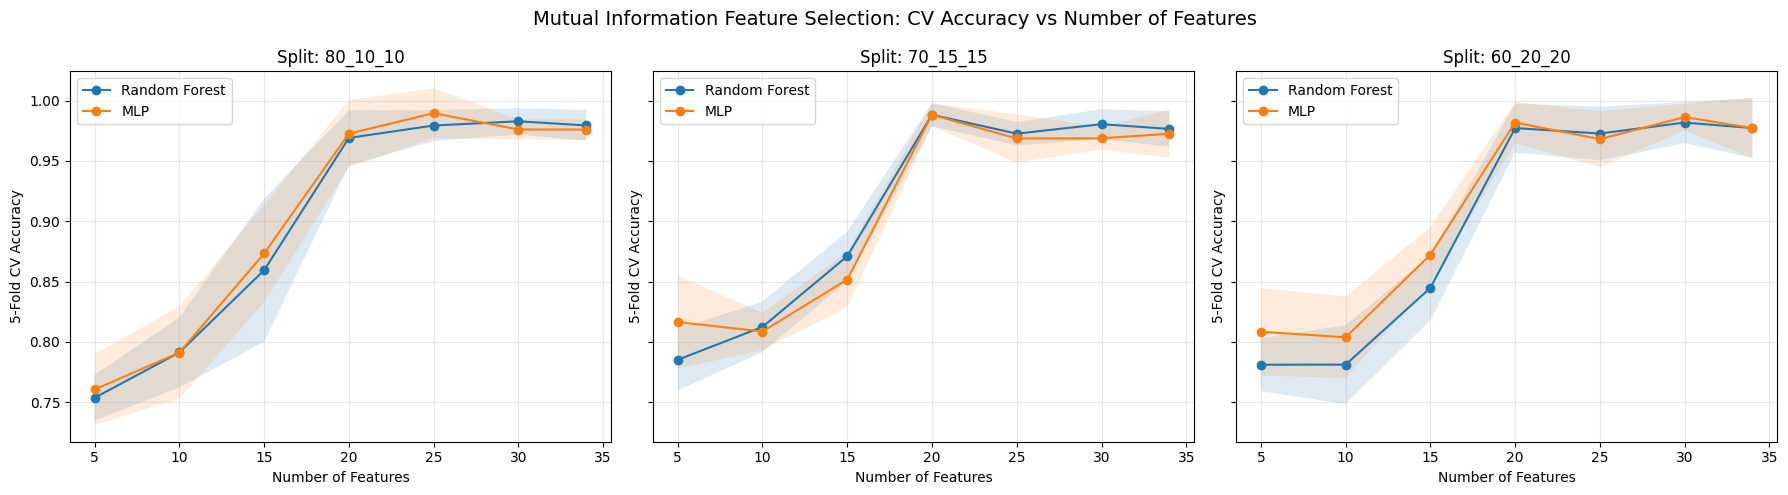

In [24]:
# Create subplots to compare feature count against cross-validation accuracy for each split ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot one chart per split ratio
for ax, split_name in zip(axes, mi_results.keys()):
    for model_name, result_df in mi_results[split_name].items():
        ax.plot(
            result_df['number_of_features'],
            result_df['cv_accuracy'],
            marker='o',
            label=model_name
        ) # Plot CV accuracy for each model
        ax.fill_between(
            result_df['number_of_features'],
            result_df['cv_accuracy'] - result_df['cv_std'],
            result_df['cv_accuracy'] + result_df['cv_std'],
            alpha=0.15
        ) # Shade the ±1 std range
    ax.set_title(f'Split: {split_name}') # Set chart title to the split ratio
    ax.set_xlabel('Number of Features') # Set x-axis label
    ax.set_ylabel('5-Fold CV Accuracy') # Set y-axis label
    ax.legend() # Show the legend
    ax.grid(True, alpha=0.3) # Add a light grid

plt.suptitle('Mutual Information Feature Selection: CV Accuracy vs Number of Features', fontsize=14) # Set overall title
plt.tight_layout() # Adjust subplot layout
plt.show() # Display the plot


In [25]:
# Create dictionaries to store the best MI result for each split ratio and each model
rf_mi_optimal_results = {}
mlp_mi_optimal_results = {}

# Extract the optimal feature indices for each split ratio and model
for split_name in mi_results.keys():
    # Get the best result for Random Forest
    rf_df = mi_results[split_name]['Random Forest']
    rf_best = rf_df.loc[rf_df['cv_accuracy'].idxmax()]
    rf_mi_optimal_results[split_name] = {
        'number_of_features': int(rf_best['number_of_features']),
        'cv_accuracy': rf_best['cv_accuracy'],
        'selected_indices': rf_best['selected_indices'],
        'selected_features': rf_best['selected_features']
    }

    # Get the best result for MLP
    mlp_df = mi_results[split_name]['MLP']
    mlp_best = mlp_df.loc[mlp_df['cv_accuracy'].idxmax()]
    mlp_mi_optimal_results[split_name] = {
        'number_of_features': int(mlp_best['number_of_features']),
        'cv_accuracy': mlp_best['cv_accuracy'],
        'selected_indices': mlp_best['selected_indices'],
        'selected_features': mlp_best['selected_features']
    }

# Display the optimal feature selection results
print('=== Optimal Feature Selection Results ===')
print('\n--- Random Forest ---')
for split_name, result in rf_mi_optimal_results.items():
    print(f"  {split_name}: {result['number_of_features']} features, CV accuracy={result['cv_accuracy']:.4f}")
    print(f"    Features: {result['selected_features']}")

print('\n--- MLP Neural Network ---')
for split_name, result in mlp_mi_optimal_results.items():
    print(f"  {split_name}: {result['number_of_features']} features, CV accuracy={result['cv_accuracy']:.4f}")
    print(f"    Features: {result['selected_features']}")


=== Optimal Feature Selection Results ===

--- Random Forest ---
  80_10_10: 30 features, CV accuracy=0.9829
    Features: ['clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'band_like_infiltrate', 'saw_tooth_appearance_of_retes', 'vacuolisation_and_damage_of_basal_layer', 'polygonal_papules', 'focal_hypergranulosis', 'spongiosis', 'melanin_incontinence', 'fibrosis_of_the_papillary_dermis', 'oral_mucosal_involvement', 'exocytosis', 'knee_and_elbow_involvement', 'munro_microabcess', 'PNL_infiltrate', 'scalp_involvement', 'definite_borders', 'disappearance_of_the_granular_layer', 'koebner_phenomenon', 'follicular_papules', 'parakeratosis', 'perifollicular_parakeratosis', 'age', 'hyperkeratosis', 'follicular_horn_plug', 'itching', 'family_history', 'scaling', 'eosinophils_in_the_infiltrate']
  70_15_15: 20 features, CV accuracy=0.9883
    Features: ['elongation_of_the_rete_ridges', 'melanin_incontinence', 'thinning_of_the_suprapapi

In [26]:
# Extract the optimal feature indices for each split ratio
rf_selected_feature_indices_80 = rf_mi_optimal_results['80_10_10']['selected_indices']
rf_selected_feature_indices_70 = rf_mi_optimal_results['70_15_15']['selected_indices']
rf_selected_feature_indices_60 = rf_mi_optimal_results['60_20_20']['selected_indices']

mlp_selected_feature_indices_80 = mlp_mi_optimal_results['80_10_10']['selected_indices']
mlp_selected_feature_indices_70 = mlp_mi_optimal_results['70_15_15']['selected_indices']
mlp_selected_feature_indices_60 = mlp_mi_optimal_results['60_20_20']['selected_indices']

# Create Random Forest MI datasets for the 80/10/10 split
rf_x_train_80_mi = rf_x_train_80.iloc[:, rf_selected_feature_indices_80]
rf_x_val_10_mi = rf_x_val_10.iloc[:, rf_selected_feature_indices_80]
rf_x_test_10_mi = rf_x_test_10.iloc[:, rf_selected_feature_indices_80]

# Create Random Forest MI datasets for the 70/15/15 split
rf_x_train_70_mi = rf_x_train_70.iloc[:, rf_selected_feature_indices_70]
rf_x_val_15_mi = rf_x_val_15.iloc[:, rf_selected_feature_indices_70]
rf_x_test_15_mi = rf_x_test_15.iloc[:, rf_selected_feature_indices_70]

# Create Random Forest MI datasets for the 60/20/20 split
rf_x_train_60_mi = rf_x_train_60.iloc[:, rf_selected_feature_indices_60]
rf_x_val_20_mi = rf_x_val_20.iloc[:, rf_selected_feature_indices_60]
rf_x_test_20_mi = rf_x_test_20.iloc[:, rf_selected_feature_indices_60]

# Create MLP MI datasets for the 80/10/10 split
mlp_x_train_80_mi = mlp_x_train_80.iloc[:, mlp_selected_feature_indices_80]
mlp_x_val_10_mi = mlp_x_val_10.iloc[:, mlp_selected_feature_indices_80]
mlp_x_test_10_mi = mlp_x_test_10.iloc[:, mlp_selected_feature_indices_80]

# Create MLP MI datasets for the 70/15/15 split
mlp_x_train_70_mi = mlp_x_train_70.iloc[:, mlp_selected_feature_indices_70]
mlp_x_val_15_mi = mlp_x_val_15.iloc[:, mlp_selected_feature_indices_70]
mlp_x_test_15_mi = mlp_x_test_15.iloc[:, mlp_selected_feature_indices_70]

# Create MLP MI datasets for the 60/20/20 split
mlp_x_train_60_mi = mlp_x_train_60.iloc[:, mlp_selected_feature_indices_60]
mlp_x_val_20_mi = mlp_x_val_20.iloc[:, mlp_selected_feature_indices_60]
mlp_x_test_20_mi = mlp_x_test_20.iloc[:, mlp_selected_feature_indices_60]

# Store all MI-selected datasets for Random Forest
rf_mi_datasets = {
    '80_10_10': {
        'X_train': rf_x_train_80_mi, 'X_val': rf_x_val_10_mi, 'X_test': rf_x_test_10_mi,
        'y_train': rf_y_train_80, 'y_val': rf_y_val_10, 'y_test': rf_y_test_10
    },
    '70_15_15': {
        'X_train': rf_x_train_70_mi, 'X_val': rf_x_val_15_mi, 'X_test': rf_x_test_15_mi,
        'y_train': rf_y_train_70, 'y_val': rf_y_val_15, 'y_test': rf_y_test_15
    },
    '60_20_20': {
        'X_train': rf_x_train_60_mi, 'X_val': rf_x_val_20_mi, 'X_test': rf_x_test_20_mi,
        'y_train': rf_y_train_60, 'y_val': rf_y_val_20, 'y_test': rf_y_test_20
    }
}

# Store all MI-selected datasets for MLP
mlp_mi_datasets = {
    '80_10_10': {
        'X_train': mlp_x_train_80_mi, 'X_val': mlp_x_val_10_mi, 'X_test': mlp_x_test_10_mi,
        'y_train': mlp_y_train_80, 'y_val': mlp_y_val_10, 'y_test': mlp_y_test_10
    },
    '70_15_15': {
        'X_train': mlp_x_train_70_mi, 'X_val': mlp_x_val_15_mi, 'X_test': mlp_x_test_15_mi,
        'y_train': mlp_y_train_70, 'y_val': mlp_y_val_15, 'y_test': mlp_y_test_15
    },
    '60_20_20': {
        'X_train': mlp_x_train_60_mi, 'X_val': mlp_x_val_20_mi, 'X_test': mlp_x_test_20_mi,
        'y_train': mlp_y_train_60, 'y_val': mlp_y_val_20, 'y_test': mlp_y_test_20
    }
}

# Display the dimensions of the MI-selected datasets
print('=== MI-Selected Feature Dataset Dimensions ===')
print('\n--- Random Forest ---')
for split_name, data in rf_mi_datasets.items():
    print(f"  {split_name}: Train={data['X_train'].shape}, Val={data['X_val'].shape}, Test={data['X_test'].shape}")

print('\n--- MLP Neural Network ---')
for split_name, data in mlp_mi_datasets.items():
    print(f"  {split_name}: Train={data['X_train'].shape}, Val={data['X_val'].shape}, Test={data['X_test'].shape}")


=== MI-Selected Feature Dataset Dimensions ===

--- Random Forest ---
  80_10_10: Train=(292, 30), Val=(37, 30), Test=(37, 30)
  70_15_15: Train=(256, 20), Val=(55, 20), Test=(55, 20)
  60_20_20: Train=(219, 30), Val=(73, 30), Test=(74, 30)

--- MLP Neural Network ---
  80_10_10: Train=(292, 25), Val=(37, 25), Test=(37, 25)
  70_15_15: Train=(256, 20), Val=(55, 20), Test=(55, 20)
  60_20_20: Train=(219, 30), Val=(73, 30), Test=(74, 30)


# Preprocessing Summary
- The CSV file was loaded without headers using column names from the dermatology README.
- The `?` missing marker was converted into `NaN`.
- Missing `age` values were imputed using the median age.
- Duplicate rows were checked.
- No outlier rows were removed as most features are ordinal (0-3). Age was visually inspected.
- The dataset was split into three train/validation/test ratios: 80/10/10, 70/15/15, and 60/20/20 using stratified sampling.
- Features were standardized using `StandardScaler` fitted on training data only.
- Mutual Information was used as the unified feature selection method for both Random Forest and MLP Neural Network.
- Candidate feature counts (5, 10, 15, 20, 25, 30, all) were evaluated using 5-fold Stratified CV.
- The optimal feature subsets were selected for each model and split ratio.

# Data Modeling
Build the machine learning models. You must build at least two (2) predictive models. One of the predictive models must be either Neural Network or Fuzzy Logic System.
______________________________________________________________________________________
Description: Two predictive models are constructed: Random Forest and MLP Neural Network. The Random Forest model is the main requested model for Part 2, and the MLP Neural Network is included as the second model required by the template. Both models reuse the preprocessing completed earlier: missing-value handling, stratified train/validation/test splits, standardisation, and Mutual Information selected feature subsets. Each model is fine-tuned with `GridSearchCV` on the training set only, selected using validation weighted F1-score, and evaluated once on the unseen test set.

## Random Forest

### Hyperparameter Fine-Tuning (GridSearchCV)

In [27]:
print('--- Starting Random Forest Hyperparameter Tuning on MI-Selected Features ---')

# Random Forest is an ensemble tree-based classifier. It is suitable here because it can model
# non-linear relationships between dermatology symptoms and disease classes.
rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter grid used for fine-tuning.
# n_estimators controls the number of trees.
# max_depth controls tree complexity and helps reduce overfitting.
# min_samples_split and min_samples_leaf control how easily trees split nodes.
# class_weight='balanced' is tested because the dermatology classes are imbalanced.
random_forest_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

rf_tuned_models = {}
rf_tuning_rows = []
best_rf_score = -1
best_rf_split = None
best_rf_model = None
best_rf_test_data = None
best_rf_params = None
best_rf_selected_features = None

# Tune one Random Forest candidate for each train/validation/test split.
for split_name, split_data in rf_mi_datasets.items():
    print()
    print(f'Fine-tuning Random Forest for {split_name} split')

    X_train_opt = split_data['X_train']
    y_train_opt = split_data['y_train']
    X_val_opt = split_data['X_val']
    y_val_opt = split_data['y_val']

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=1),
        param_grid=random_forest_param_grid,
        scoring='f1_weighted',
        cv=rf_cv,
        n_jobs=1,
        return_train_score=True
    )

    # Fit only on the training data. Validation and test data are kept unseen during tuning.
    grid_search.fit(X_train_opt, y_train_opt)
    best_model_for_split = grid_search.best_estimator_
    val_predictions = best_model_for_split.predict(X_val_opt)

    val_accuracy = accuracy_score(y_val_opt, val_predictions)
    val_precision_weighted = precision_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
    val_recall_weighted = recall_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
    val_f1_weighted = f1_score(y_val_opt, val_predictions, average='weighted', zero_division=0)

    selected_features = rf_mi_optimal_results[split_name]['selected_features']
    rf_tuned_models[split_name] = best_model_for_split
    rf_tuning_rows.append({
        'model': 'Random Forest',
        'split_ratio': split_name,
        'number_of_features': rf_mi_optimal_results[split_name]['number_of_features'],
        'selected_features': selected_features,
        'best_params': grid_search.best_params_,
        'cv_f1_weighted': grid_search.best_score_,
        'validation_accuracy': val_accuracy,
        'validation_precision_weighted': val_precision_weighted,
        'validation_recall_weighted': val_recall_weighted,
        'validation_f1_weighted': val_f1_weighted
    })

    print('Best parameters:', grid_search.best_params_)
    print('Cross-validation weighted F1:', round(grid_search.best_score_, 4))
    print('Validation weighted F1:', round(val_f1_weighted, 4))

    # Select the final Random Forest candidate using validation weighted F1-score.
    if val_f1_weighted > best_rf_score:
        best_rf_score = val_f1_weighted
        best_rf_split = split_name
        best_rf_model = best_model_for_split
        best_rf_test_data = (split_data['X_test'], split_data['y_test'])
        best_rf_params = grid_search.best_params_
        best_rf_selected_features = selected_features

rf_tuning_summary = pd.DataFrame(rf_tuning_rows)
rf_metric_columns = [
    'cv_f1_weighted',
    'validation_accuracy',
    'validation_precision_weighted',
    'validation_recall_weighted',
    'validation_f1_weighted'
]
rf_tuning_summary[rf_metric_columns] = rf_tuning_summary[rf_metric_columns].round(4)

print()
print(f'Best Random Forest split: {best_rf_split}')
print('Best Random Forest validation weighted F1:', round(best_rf_score, 4))
print('Best Random Forest parameters:', best_rf_params)
print('Selected features used by final Random Forest model:', best_rf_selected_features)

rf_tuning_summary

--- Starting Random Forest Hyperparameter Tuning on MI-Selected Features ---

Fine-tuning Random Forest for 80_10_10 split


Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Cross-validation weighted F1: 0.9861
Validation weighted F1: 1.0

Fine-tuning Random Forest for 70_15_15 split


Best parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Cross-validation weighted F1: 0.9879
Validation weighted F1: 0.9816

Fine-tuning Random Forest for 60_20_20 split


Best parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Cross-validation weighted F1: 0.9811
Validation weighted F1: 0.9321

Best Random Forest split: 80_10_10
Best Random Forest validation weighted F1: 1.0
Best Random Forest parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Selected features used by final Random Forest model: ['clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'band_like_infiltrate', 'saw_tooth_appearance_of_retes', 'vacuolisation_and_damage_of_basal_layer', 'polygonal_papules', 'focal_hypergranulosis', 'spongiosis', 'melanin_incontinence', 'fibrosis_of_the_papillary_dermis', 'oral_mucosal_involvement', 'exocytosis', 'knee_and_elbow_involvement', 'munro_microabcess', 'PNL_infiltrate', 'scalp_involvement', 'definite_borders', 'disappearance_of_the_granular_layer', 'k

,model,split_ratio,number_of_features,selected_features,best_params,cv_f1_weighted,validation_accuracy,validation_precision_weighted,validation_recall_weighted,validation_f1_weighted
0,Random Forest,80_10_10,30,"[clubbing_of_the_rete_ridges, elongation_of_th...","{'class_weight': 'balanced', 'max_depth': None...",0.9861,1.0000,1.0000,1.0000,1.0000
1,Random Forest,70_15_15,20,"[elongation_of_the_rete_ridges, melanin_incont...","{'class_weight': None, 'max_depth': None, 'min...",0.9879,0.9818,0.9836,0.9818,0.9816
2,Random Forest,60_20_20,30,"[elongation_of_the_rete_ridges, clubbing_of_th...","{'class_weight': None, 'max_depth': None, 'min...",0.9811,0.9315,0.9390,0.9315,0.9321


### Final Evaluation on Unseen Test Set

In [28]:
# Evaluate the validation-selected Random Forest model once on the unseen test set.
rf_X_test_final, rf_y_test_final = best_rf_test_data
rf_test_predictions = best_rf_model.predict(rf_X_test_final)

rf_class_labels = sorted(rf_y_test_final.unique())
rf_target_names = [class_names[label] for label in rf_class_labels]

random_forest_test_metrics = {
    'model': 'Random Forest',
    'dataset': 'Test',
    'split_ratio': best_rf_split,
    'accuracy': accuracy_score(rf_y_test_final, rf_test_predictions),
    'precision_weighted': precision_score(rf_y_test_final, rf_test_predictions, average='weighted', zero_division=0),
    'recall_weighted': recall_score(rf_y_test_final, rf_test_predictions, average='weighted', zero_division=0),
    'f1_weighted': f1_score(rf_y_test_final, rf_test_predictions, average='weighted', zero_division=0),
    'precision_macro': precision_score(rf_y_test_final, rf_test_predictions, average='macro', zero_division=0),
    'recall_macro': recall_score(rf_y_test_final, rf_test_predictions, average='macro', zero_division=0),
    'f1_macro': f1_score(rf_y_test_final, rf_test_predictions, average='macro', zero_division=0)
}

print('=== Final Random Forest Evaluation ===')
print(f'Evaluating the best Random Forest model from the {best_rf_split} split on the unseen test set.')
print()
print('--- Core Classification Performance Metrics ---')
print(f"Accuracy  : {random_forest_test_metrics['accuracy']:.4f}")
print(f"Precision : {random_forest_test_metrics['precision_weighted']:.4f} (Weighted Average)")
print(f"Recall    : {random_forest_test_metrics['recall_weighted']:.4f} (Weighted Average)")
print(f"F1-Score  : {random_forest_test_metrics['f1_weighted']:.4f} (Weighted Average)")
print()
print('--- Detailed Classification Report ---')
print(classification_report(
    rf_y_test_final,
    rf_test_predictions,
    labels=rf_class_labels,
    target_names=rf_target_names,
    zero_division=0
))
print('Regression metrics such as R2 score, mean squared error and mean absolute error are not reported because this is a multi-class classification problem, not a regression problem.')

=== Final Random Forest Evaluation ===
Evaluating the best Random Forest model from the 80_10_10 split on the unseen test set.

--- Core Classification Performance Metrics ---
Accuracy  : 0.9189
Precision : 0.9225 (Weighted Average)
Recall    : 0.9189 (Weighted Average)
F1-Score  : 0.9189 (Weighted Average)

--- Detailed Classification Report ---
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        12
     seboreic dermatitis       0.80      0.67      0.73         6
           lichen planus       1.00      1.00      1.00         7
        pityriasis rosea       0.67      0.80      0.73         5
       cronic dermatitis       1.00      1.00      1.00         5
pityriasis rubra pilaris       1.00      1.00      1.00         2

                accuracy                           0.92        37
               macro avg       0.91      0.91      0.91        37
            weighted avg       0.92      0.92      0.92

### Confusion Matrix

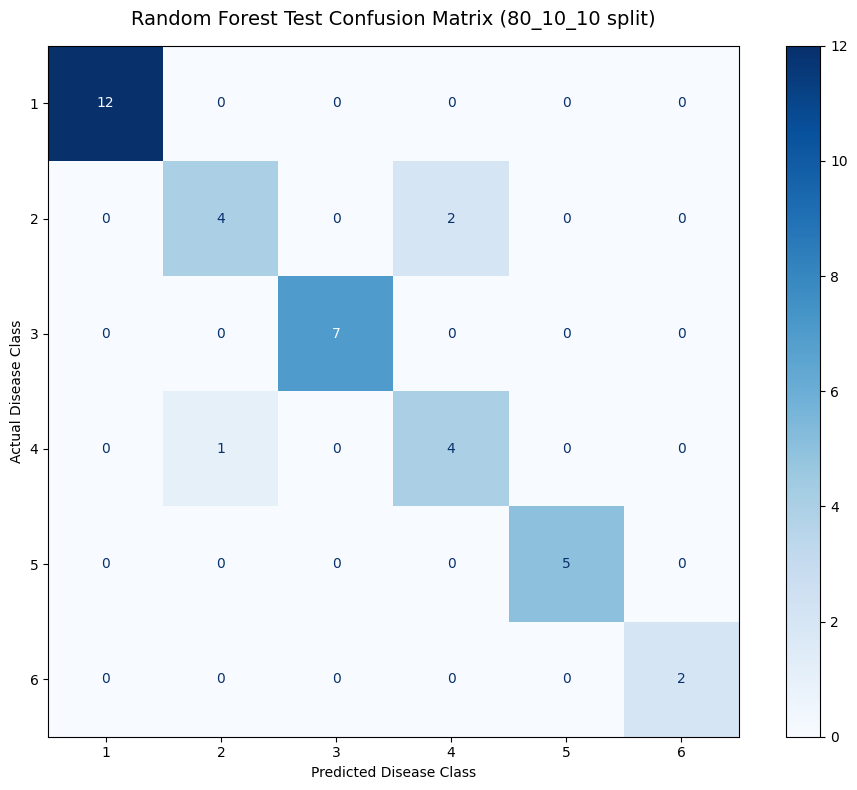

In [29]:
# Display the confusion matrix for the final Random Forest model.
rf_cm = confusion_matrix(
    rf_y_test_final,
    rf_test_predictions,
    labels=rf_class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=rf_class_labels
).plot(
    cmap='Blues',
    ax=ax,
    values_format='d'
)

plt.title(f'Random Forest Test Confusion Matrix ({best_rf_split} split)', fontsize=14, pad=15)
plt.xlabel('Predicted Disease Class')
plt.ylabel('Actual Disease Class')
plt.tight_layout()
plt.show()

### Results and Discussion: Random Forest

#### Random Forest Discussion

The Random Forest model reuses the preprocessing completed earlier by the team: missing `age` values are imputed, duplicate rows are checked, the data is split into stratified training, validation and test sets, and Mutual Information is used to select the most relevant features. Although Random Forest does not require feature scaling, the same preprocessed feature tables are reused so that the model construction remains consistent with the prepared pipeline.

Hyperparameter fine-tuning is performed with `GridSearchCV` on the training set only. The tuned parameters include the number of trees, maximum tree depth, minimum samples required for node splitting, minimum samples per leaf, and class weighting. These parameters control the bias-variance trade-off: deeper trees can fit more complex patterns, while larger leaf/split requirements and balanced class weights can reduce overfitting and improve performance on minority classes.

The best Random Forest configuration is selected using validation weighted F1-score, not the test set. Weighted F1-score is used because the dermatology class distribution is imbalanced, so the selected model should perform well across precision and recall while accounting for class support. After selection, the model is evaluated once on the unseen test set using accuracy, precision, recall, F1-score, a classification report and a confusion matrix.

Because the target variable `class` represents six disease categories, this is a classification problem. Regression metrics such as R2 score, mean squared error and mean absolute error are not suitable for this task.

## MLP Neural Network

### Hyperparameter Fine-Tuning (GridSearchCV)

In [30]:
print('--- Starting MLP Neural Network Hyperparameter Tuning on MI-Selected Features ---')

# The MLP Neural Network is included as the second predictive model required by the template.
# It is trained on the same preprocessed and MI-selected feature subsets for a fair comparison.
mlp_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

mlp_tuned_models = {}
mlp_tuning_rows = []
best_mlp_score = -1
best_mlp_split = None
best_mlp_model = None
best_mlp_test_data = None
best_mlp_params = None
best_mlp_selected_features = None

for split_name, split_data in mlp_mi_datasets.items():
    print()
    print(f'Fine-tuning MLP Neural Network for {split_name} split')

    X_train_opt = split_data['X_train']
    y_train_opt = split_data['y_train']
    X_val_opt = split_data['X_val']
    y_val_opt = split_data['y_val']

    grid_search = GridSearchCV(
        estimator=MLPClassifier(max_iter=1000, random_state=42, early_stopping=True),
        param_grid=mlp_param_grid,
        scoring='f1_weighted',
        cv=mlp_cv,
        n_jobs=1,
        return_train_score=True
    )

    grid_search.fit(X_train_opt, y_train_opt)
    best_model_for_split = grid_search.best_estimator_
    val_predictions = best_model_for_split.predict(X_val_opt)

    val_accuracy = accuracy_score(y_val_opt, val_predictions)
    val_precision_weighted = precision_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
    val_recall_weighted = recall_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
    val_f1_weighted = f1_score(y_val_opt, val_predictions, average='weighted', zero_division=0)

    selected_features = mlp_mi_optimal_results[split_name]['selected_features']
    mlp_tuned_models[split_name] = best_model_for_split
    mlp_tuning_rows.append({
        'model': 'MLP Neural Network',
        'split_ratio': split_name,
        'number_of_features': mlp_mi_optimal_results[split_name]['number_of_features'],
        'selected_features': selected_features,
        'best_params': grid_search.best_params_,
        'cv_f1_weighted': grid_search.best_score_,
        'validation_accuracy': val_accuracy,
        'validation_precision_weighted': val_precision_weighted,
        'validation_recall_weighted': val_recall_weighted,
        'validation_f1_weighted': val_f1_weighted
    })

    print('Best parameters:', grid_search.best_params_)
    print('Cross-validation weighted F1:', round(grid_search.best_score_, 4))
    print('Validation weighted F1:', round(val_f1_weighted, 4))

    if val_f1_weighted > best_mlp_score:
        best_mlp_score = val_f1_weighted
        best_mlp_split = split_name
        best_mlp_model = best_model_for_split
        best_mlp_test_data = (split_data['X_test'], split_data['y_test'])
        best_mlp_params = grid_search.best_params_
        best_mlp_selected_features = selected_features

mlp_tuning_summary = pd.DataFrame(mlp_tuning_rows)
mlp_metric_columns = [
    'cv_f1_weighted',
    'validation_accuracy',
    'validation_precision_weighted',
    'validation_recall_weighted',
    'validation_f1_weighted'
]
mlp_tuning_summary[mlp_metric_columns] = mlp_tuning_summary[mlp_metric_columns].round(4)

print()
print(f'Best MLP split: {best_mlp_split}')
print('Best MLP validation weighted F1:', round(best_mlp_score, 4))
print('Best MLP parameters:', best_mlp_params)
print('Selected features used by final MLP model:', best_mlp_selected_features)

mlp_tuning_summary

--- Starting MLP Neural Network Hyperparameter Tuning on MI-Selected Features ---

Fine-tuning MLP Neural Network for 80_10_10 split


Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}
Cross-validation weighted F1: 0.9688
Validation weighted F1: 1.0

Fine-tuning MLP Neural Network for 70_15_15 split


Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Cross-validation weighted F1: 0.9798
Validation weighted F1: 0.9619

Fine-tuning MLP Neural Network for 60_20_20 split


Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
Cross-validation weighted F1: 0.9719
Validation weighted F1: 0.9726

Best MLP split: 80_10_10
Best MLP validation weighted F1: 1.0
Best MLP parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}
Selected features used by final MLP model: ['clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'band_like_infiltrate', 'saw_tooth_appearance_of_retes', 'vacuolisation_and_damage_of_basal_layer', 'polygonal_papules', 'focal_hypergranulosis', 'spongiosis', 'melanin_incontinence', 'fibrosis_of_the_papillary_dermis', 'oral_mucosal_involvement', 'exocytosis', 'knee_and_elbow_involvement', 'munro_microabcess', 'PNL_infiltrate', 'scalp_involvement', 'definite_borders', 'disappearance_of_the_granular_layer', 'koebner_phenomenon', 'follicular_papules', 'parakeratosis', 'perifollicu

,model,split_ratio,number_of_features,selected_features,best_params,cv_f1_weighted,validation_accuracy,validation_precision_weighted,validation_recall_weighted,validation_f1_weighted
0,MLP Neural Network,80_10_10,25,"[clubbing_of_the_rete_ridges, elongation_of_th...","{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.9688,1.0000,1.0000,1.0000,1.0000
1,MLP Neural Network,70_15_15,20,"[elongation_of_the_rete_ridges, melanin_incont...","{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.9798,0.9636,0.9665,0.9636,0.9619
2,MLP Neural Network,60_20_20,30,"[elongation_of_the_rete_ridges, clubbing_of_th...","{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.9719,0.9726,0.9726,0.9726,0.9726


### Final Evaluation on Unseen Test Set

In [31]:
# Evaluate the validation-selected MLP model once on the unseen test set.
mlp_X_test_final, mlp_y_test_final = best_mlp_test_data
mlp_test_predictions = best_mlp_model.predict(mlp_X_test_final)

mlp_class_labels = sorted(mlp_y_test_final.unique())
mlp_target_names = [class_names[label] for label in mlp_class_labels]

mlp_test_metrics = {
    'model': 'MLP Neural Network',
    'dataset': 'Test',
    'split_ratio': best_mlp_split,
    'accuracy': accuracy_score(mlp_y_test_final, mlp_test_predictions),
    'precision_weighted': precision_score(mlp_y_test_final, mlp_test_predictions, average='weighted', zero_division=0),
    'recall_weighted': recall_score(mlp_y_test_final, mlp_test_predictions, average='weighted', zero_division=0),
    'f1_weighted': f1_score(mlp_y_test_final, mlp_test_predictions, average='weighted', zero_division=0),
    'precision_macro': precision_score(mlp_y_test_final, mlp_test_predictions, average='macro', zero_division=0),
    'recall_macro': recall_score(mlp_y_test_final, mlp_test_predictions, average='macro', zero_division=0),
    'f1_macro': f1_score(mlp_y_test_final, mlp_test_predictions, average='macro', zero_division=0)
}

print('=== Final MLP Neural Network Evaluation ===')
print(f'Evaluating the best MLP model from the {best_mlp_split} split on the unseen test set.')
print()
print('--- Core Classification Performance Metrics ---')
print(f"Accuracy  : {mlp_test_metrics['accuracy']:.4f}")
print(f"Precision : {mlp_test_metrics['precision_weighted']:.4f} (Weighted Average)")
print(f"Recall    : {mlp_test_metrics['recall_weighted']:.4f} (Weighted Average)")
print(f"F1-Score  : {mlp_test_metrics['f1_weighted']:.4f} (Weighted Average)")
print()
print('--- Detailed Classification Report ---')
print(classification_report(
    mlp_y_test_final,
    mlp_test_predictions,
    labels=mlp_class_labels,
    target_names=mlp_target_names,
    zero_division=0
))
print('Regression metrics such as R2 score, mean squared error and mean absolute error are not reported because this is a multi-class classification problem, not a regression problem.')

=== Final MLP Neural Network Evaluation ===
Evaluating the best MLP model from the 80_10_10 split on the unseen test set.

--- Core Classification Performance Metrics ---
Accuracy  : 0.9459
Precision : 0.9459 (Weighted Average)
Recall    : 0.9459 (Weighted Average)
F1-Score  : 0.9459 (Weighted Average)

--- Detailed Classification Report ---
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        12
     seboreic dermatitis       0.83      0.83      0.83         6
           lichen planus       1.00      1.00      1.00         7
        pityriasis rosea       0.80      0.80      0.80         5
       cronic dermatitis       1.00      1.00      1.00         5
pityriasis rubra pilaris       1.00      1.00      1.00         2

                accuracy                           0.95        37
               macro avg       0.94      0.94      0.94        37
            weighted avg       0.95      0.95      0.95     

### Confusion Matrix

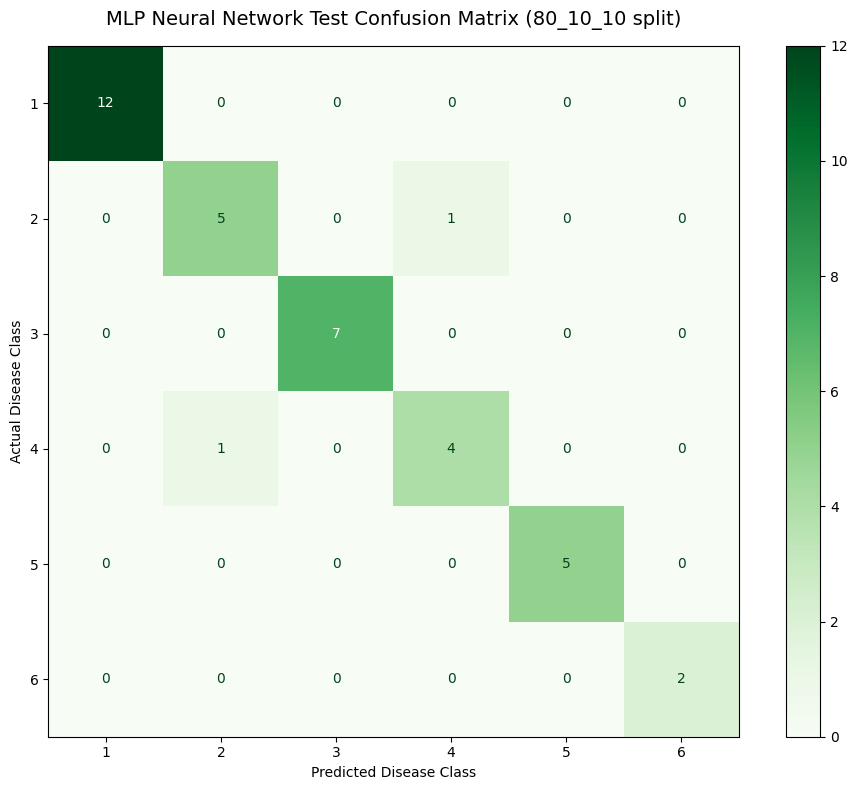

In [32]:
# Display the confusion matrix for the final MLP Neural Network model.
mlp_cm = confusion_matrix(
    mlp_y_test_final,
    mlp_test_predictions,
    labels=mlp_class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=mlp_cm,
    display_labels=mlp_class_labels
).plot(
    cmap='Greens',
    ax=ax,
    values_format='d'
)

plt.title(f'MLP Neural Network Test Confusion Matrix ({best_mlp_split} split)', fontsize=14, pad=15)
plt.xlabel('Predicted Disease Class')
plt.ylabel('Actual Disease Class')
plt.tight_layout()
plt.show()

### Results and Discussion: MLP Neural Network

#### MLP Neural Network Discussion

The MLP Neural Network is used as the second predictive model required by the Part 2 template. It reuses the same preprocessing pipeline and MI-selected feature subsets so that its performance can be compared fairly with Random Forest. Unlike Random Forest, MLP is sensitive to feature scale, so the standardised features prepared earlier are important for stable training.

The tuned MLP parameters include hidden layer structure, activation function, L2 regularisation strength (`alpha`) and learning rate. These parameters affect model capacity, non-linear learning behaviour and overfitting control. The best MLP candidate is selected using validation weighted F1-score, and the unseen test set is used only after model selection for final reporting.

The final comparison should focus on weighted F1-score together with accuracy, precision, recall and the confusion matrix. If MLP performs worse than Random Forest, a likely explanation is that the dermatology dataset is small, while MLP generally requires more data to learn stable neural representations. If MLP performs better, it suggests that the standardised MI-selected features contain non-linear patterns that the neural network captures effectively.

# Evaluate the Models
Perform a comparison between the predictive models. <br>
Report the accuracy, recall, precision and F1-score measures as well as the confusion matrix (classification problem). <br>
Report the R2 score, mean squared error and mean absolute error if it is a regression problem.
______________________________________________________________________________________
Description: This is a multi-class classification problem because the target variable `class` contains six dermatology disease categories. Therefore, accuracy, precision, recall, F1-score, classification reports and confusion matrices are reported. Regression metrics such as R2 score, mean squared error and mean absolute error are not applicable. The final model comparison uses the unseen test-set metrics only for reporting generalisation performance; model selection was already performed using validation weighted F1-score.

In [33]:
# Build the final model comparison table required by the rubric.
final_model_comparison_df = pd.DataFrame([
    random_forest_test_metrics,
    mlp_test_metrics
])

comparison_columns = [
    'model',
    'split_ratio',
    'accuracy',
    'precision_weighted',
    'recall_weighted',
    'f1_weighted',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]
final_model_comparison_df = final_model_comparison_df[comparison_columns]

numeric_columns = [
    'accuracy',
    'precision_weighted',
    'recall_weighted',
    'f1_weighted',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]
final_model_comparison_df[numeric_columns] = final_model_comparison_df[numeric_columns].round(4)

print('=== Final Model Comparison: Random Forest vs MLP Neural Network ===')
display(final_model_comparison_df)

best_reported_model = final_model_comparison_df.sort_values(by='f1_weighted', ascending=False).iloc[0]
print(f"Best reported test performance: {best_reported_model['model']}")
print('Interpretation: this model achieved the highest weighted F1-score on the unseen test set among the two validation-selected final models.')
print('Note: the test set was used only for final reporting, not for hyperparameter tuning or model selection.')
print()
print('Random Forest justification: Random Forest is well suited for this dataset because it handles non-linear feature interactions, works well on small tabular datasets, and is robust to noisy or less informative features through ensemble averaging.')
print('MLP comparison note: MLP is included to satisfy the neural-network model requirement and to compare against Random Forest, but it may be less stable on a small dataset because neural networks usually benefit from larger training samples.')

=== Final Model Comparison: Random Forest vs MLP Neural Network ===


,model,split_ratio,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Random Forest,80_10_10,0.9189,0.9225,0.9189,0.9189,0.9111,0.9111,0.9091
1,MLP Neural Network,80_10_10,0.9459,0.9459,0.9459,0.9459,0.9389,0.9389,0.9389


Best reported test performance: MLP Neural Network
Interpretation: this model achieved the highest weighted F1-score on the unseen test set among the two validation-selected final models.
Note: the test set was used only for final reporting, not for hyperparameter tuning or model selection.

Random Forest justification: Random Forest is well suited for this dataset because it handles non-linear feature interactions, works well on small tabular datasets, and is robust to noisy or less informative features through ensemble averaging.
MLP comparison note: MLP is included to satisfy the neural-network model requirement and to compare against Random Forest, but it may be less stable on a small dataset because neural networks usually benefit from larger training samples.
